## ***Import Required Libraries***

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from scipy.stats import pearsonr

In [2]:
# Load dataset
df = pd.read_csv(r"C:\Users\saket\Downloads\all_upwork_jobs_2024-02-07-2024-03-24 (1).csv")

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Shape: (244828, 8)

Columns:
['title', 'link', 'published_date', 'is_hourly', 'hourly_low', 'hourly_high', 'budget', 'country']


,title,link,published_date,is_hourly,hourly_low,hourly_high,budget,country
0,Experienced Media Buyer For Solar Pannel and R...,https://www.upwork.com/jobs/Experienced-Media-...,2024-02-17 09:09:54+00:00,False,NaN,NaN,500.0,NaN
1,Full Stack Developer,https://www.upwork.com/jobs/Full-Stack-Develop...,2024-02-17 09:09:17+00:00,False,NaN,NaN,1100.0,United States
2,SMMA Bubble App,https://www.upwork.com/jobs/SMMA-Bubble-App_%7...,2024-02-17 09:08:46+00:00,True,10.0,30.0,NaN,United States
3,Talent Hunter Specialized in Marketing,https://www.upwork.com/jobs/Talent-Hunter-Spec...,2024-02-17 09:08:08+00:00,True,NaN,NaN,NaN,United States
4,Data Engineer,https://www.upwork.com/jobs/Data-Engineer_%7E0...,2024-02-17 09:07:42+00:00,False,NaN,NaN,650.0,India


In [3]:
# Select hourly jobs
hourly_df = df[df['is_hourly'] == True].copy()

# Calculate midpoint hourly rate
hourly_df['hourly_rate'] = (
    hourly_df['hourly_low'] + hourly_df['hourly_high']
) / 2

# Remove rows where rate or title is missing
hourly_df = hourly_df.dropna(
    subset=['title', 'hourly_rate']
)

print("Total hourly jobs:", len(hourly_df))

hourly_df[['title', 'hourly_low', 'hourly_high', 'hourly_rate']].head()

Total hourly jobs: 98775


,title,hourly_low,hourly_high,hourly_rate
2,SMMA Bubble App,10.0,30.0,20.0
7,need Portuguese writers who can understand and...,7.0,22.0,14.5
13,URGENT: Fix Emails Not Working on Discourse In...,40.0,75.0,57.5
15,Web3 Full-stack Developer,30.0,50.0,40.0
18,"Website design, UI/UX Design",12.0,30.0,21.0


In [4]:
#Basic salary statistics
print("Hourly Rate Statistics")
print("----------------------")

print("Mean:", round(hourly_df['hourly_rate'].mean(), 2))
print("Median:", round(hourly_df['hourly_rate'].median(), 2))
print("Minimum:", round(hourly_df['hourly_rate'].min(), 2))
print("Maximum:", round(hourly_df['hourly_rate'].max(), 2))

print("\nPercentiles:")
print(hourly_df['hourly_rate'].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

Hourly Rate Statistics
----------------------
Mean: 29.71
Median: 22.5
Minimum: 3.0
Maximum: 998.5

Percentiles:
0.25     14.0
0.50     22.5
0.75     35.0
0.90     57.0
0.95     75.0
0.99    135.0
Name: hourly_rate, dtype: float64


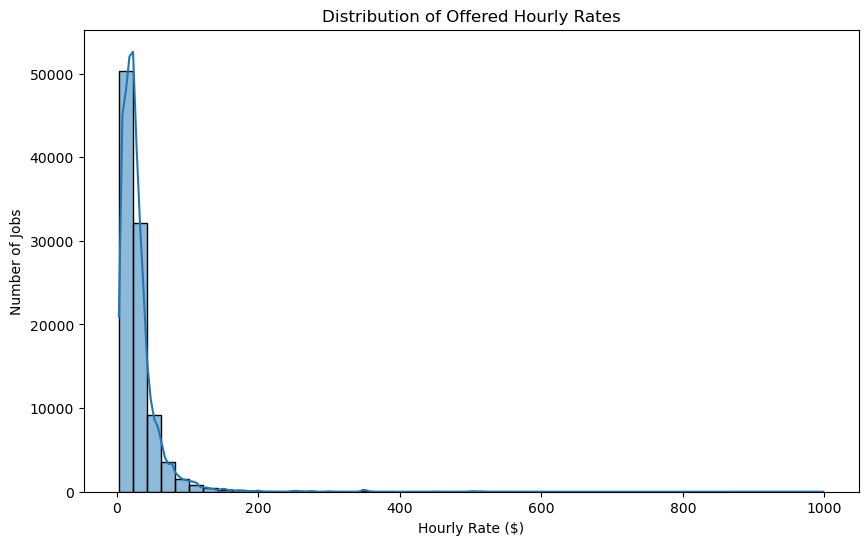

In [5]:
plt.figure(figsize=(10, 6))

sns.histplot(
    hourly_df['hourly_rate'],
    bins=50,
    kde=True
)

plt.title('Distribution of Offered Hourly Rates')
plt.xlabel('Hourly Rate ($)')
plt.ylabel('Number of Jobs')

plt.show()

In [6]:
keywords = [
    'python',
    'sql',
    'javascript',
    'react',
    'developer',
    'engineer',
    'analyst',
    'consultant',
    'financial',
    'tax',
    'ads',
    'google',
    'marketing',
    'seo',
    'sales',
    'graphic',
    'video',
    'content',
    'wordpress',
    'shopify',
    'social',
    'virtual',
    'assistant'
]

In [7]:
keyword_results = []

for keyword in keywords:

    pattern = r'(?<![a-z0-9])' + re.escape(keyword) + r'(?![a-z0-9])'

    mask = (
        hourly_df['title']
        .fillna('')
        .str.lower()
        .str.contains(pattern, regex=True)
    )

    if mask.sum() > 0:

        keyword_results.append({
            'keyword': keyword,
            'job_count': mask.sum(),
            'average_rate': hourly_df.loc[mask, 'hourly_rate'].mean(),
            'median_rate': hourly_df.loc[mask, 'hourly_rate'].median()
        })

keyword_results_df = pd.DataFrame(keyword_results)

keyword_results_df = keyword_results_df.sort_values(
    'average_rate',
    ascending=False
)

keyword_results_df

,keyword,job_count,average_rate,median_rate
9,tax,640,55.553125,50.00
8,financial,553,55.197107,37.50
7,consultant,885,51.505650,40.00
5,engineer,1509,37.890987,32.50
14,sales,1999,35.933967,16.00
6,analyst,647,35.812983,27.50
1,sql,173,34.997110,32.50
10,ads,2688,34.847284,25.00
11,google,2751,30.872228,25.00
2,javascript,266,29.785714,25.00


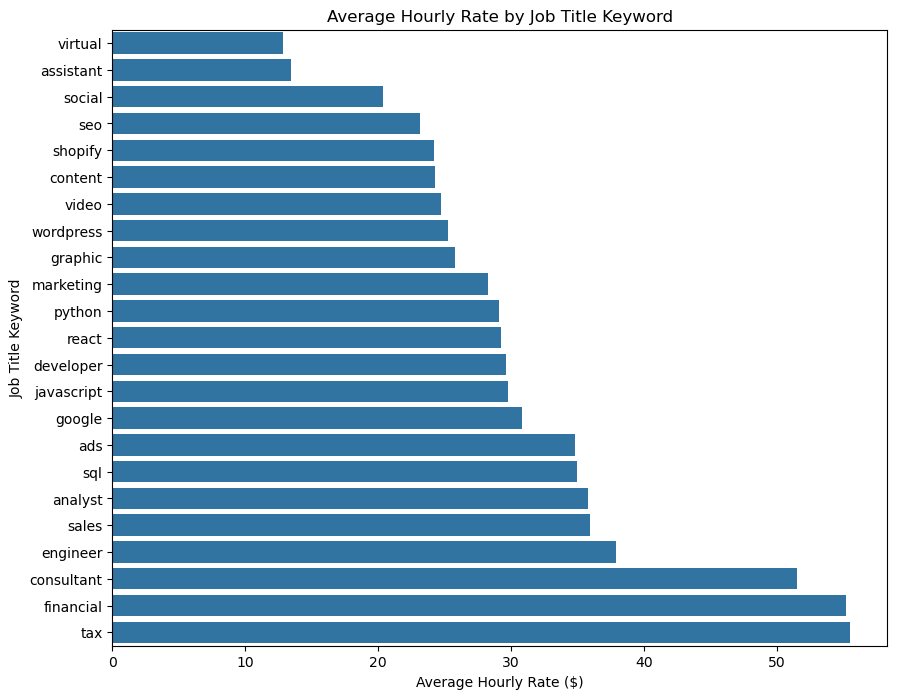

In [8]:
plot_df = keyword_results_df.sort_values(
    'average_rate',
    ascending=True
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=plot_df,
    x='average_rate',
    y='keyword'
)

plt.title('Average Hourly Rate by Job Title Keyword')
plt.xlabel('Average Hourly Rate ($)')
plt.ylabel('Job Title Keyword')

plt.show()

In [9]:
correlation_results = []

for keyword in keywords:

    pattern = r'(?<![a-z0-9])' + re.escape(keyword) + r'(?![a-z0-9])'

    keyword_present = (
        hourly_df['title']
        .fillna('')
        .str.lower()
        .str.contains(pattern, regex=True)
        .astype(int)
    )

    correlation, p_value = pearsonr(
        keyword_present,
        hourly_df['hourly_rate']
    )

    correlation_results.append({
        'keyword': keyword,
        'job_count': keyword_present.sum(),
        'correlation': correlation,
        'p_value': p_value
    })

correlation_df = pd.DataFrame(correlation_results)

correlation_df = correlation_df.sort_values(
    'correlation',
    ascending=False
)

correlation_df

,keyword,job_count,correlation,p_value
9,tax,640,0.068454,6.699325e-103
7,consultant,885,0.067975,1.724773e-101
8,financial,553,0.062727,1.114544e-86
5,engineer,1509,0.033425,7.950944e-26
14,sales,1999,0.029343,2.863412e-20
10,ads,2688,0.028187,7.982247e-19
6,analyst,647,0.016256,3.233563e-07
1,sql,173,0.007265,2.241761e-02
11,google,2751,0.006456,4.244552e-02
2,javascript,266,0.000130,9.673347e-01


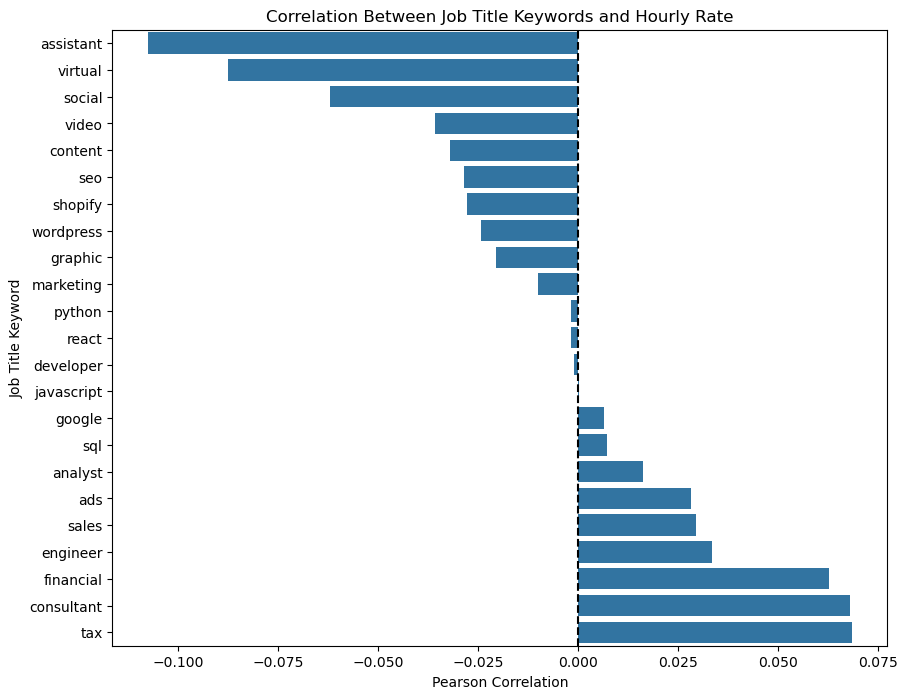

In [10]:
corr_plot = correlation_df.sort_values(
    'correlation',
    ascending=True
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=corr_plot,
    x='correlation',
    y='keyword'
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--'
)

plt.title('Correlation Between Job Title Keywords and Hourly Rate')
plt.xlabel('Pearson Correlation')
plt.ylabel('Job Title Keyword')

plt.show()

In [11]:
comparison_results = []

for keyword in keywords:

    pattern = r'(?<![a-z0-9])' + re.escape(keyword) + r'(?![a-z0-9])'

    mask = (
        hourly_df['title']
        .fillna('')
        .str.lower()
        .str.contains(pattern, regex=True)
    )

    comparison_results.append({
        'keyword': keyword,
        'jobs_with_keyword': mask.sum(),
        'average_with_keyword': hourly_df.loc[mask, 'hourly_rate'].mean(),
        'average_without_keyword': hourly_df.loc[~mask, 'hourly_rate'].mean(),
        'median_with_keyword': hourly_df.loc[mask, 'hourly_rate'].median(),
        'median_without_keyword': hourly_df.loc[~mask, 'hourly_rate'].median()
    })

comparison_df = pd.DataFrame(comparison_results)

comparison_df['average_difference'] = (
    comparison_df['average_with_keyword']
    - comparison_df['average_without_keyword']
)

comparison_df.sort_values(
    'average_difference',
    ascending=False
)

,keyword,jobs_with_keyword,average_with_keyword,average_without_keyword,median_with_keyword,median_without_keyword,average_difference
9,tax,640,55.553125,29.540719,50.00,22.5,26.012406
8,financial,553,55.197107,29.565764,37.50,22.5,25.631342
7,consultant,885,51.505650,29.512208,40.00,22.5,21.993442
5,engineer,1509,37.890987,29.582331,32.50,22.5,8.308656
14,sales,1999,35.933967,29.580686,16.00,22.5,6.353281
6,analyst,647,35.812983,29.669019,27.50,22.5,6.143964
1,sql,173,34.997110,29.699986,32.50,22.5,5.297124
10,ads,2688,34.847284,29.565529,25.00,22.5,5.281755
11,google,2751,30.872228,29.675946,25.00,22.5,1.196283
2,javascript,266,29.785714,29.709057,25.00,22.5,0.076657


In [12]:
print("Top 10 keywords by average hourly rate:")
print(
    keyword_results_df[
        ['keyword', 'job_count', 'average_rate', 'median_rate']
    ].head(10)
)

print("\nTop 10 positive correlations:")
print(
    correlation_df[
        ['keyword', 'job_count', 'correlation', 'p_value']
    ].head(10)
)

print("\nTop 10 negative correlations:")
print(
    correlation_df[
        ['keyword', 'job_count', 'correlation', 'p_value']
    ].tail(10)
)

Top 10 keywords by average hourly rate:
       keyword  job_count  average_rate  median_rate
9          tax        640     55.553125         50.0
8    financial        553     55.197107         37.5
7   consultant        885     51.505650         40.0
5     engineer       1509     37.890987         32.5
14       sales       1999     35.933967         16.0
6      analyst        647     35.812983         27.5
1          sql        173     34.997110         32.5
10         ads       2688     34.847284         25.0
11      google       2751     30.872228         25.0
2   javascript        266     29.785714         25.0

Top 10 positive correlations:
       keyword  job_count  correlation        p_value
9          tax        640     0.068454  6.699325e-103
7   consultant        885     0.067975  1.724773e-101
8    financial        553     0.062727   1.114544e-86
5     engineer       1509     0.033425   7.950944e-26
14       sales       1999     0.029343   2.863412e-20
10         ads       2

In [13]:
# Create a copy for Task 2
task2_df = df.copy()

# Convert published_date to datetime
task2_df['published_date'] = pd.to_datetime(
    task2_df['published_date'],
    errors='coerce'
)

# Clean job titles
task2_df['title'] = task2_df['title'].fillna('').str.lower()

print("Date Range:")
print(task2_df['published_date'].min())
print(task2_df['published_date'].max())

Date Range:
2023-11-02 09:22:02+00:00
2024-03-24 14:16:47+00:00


In [14]:
categories = {
    'AI & Data': [
        'artificial intelligence',
        'machine learning',
        'data science',
        'data analyst',
        'data engineer',
        'data scientist',
        'deep learning',
        'nlp',
        'python',
        'sql'
    ],

    'Software Development': [
        'developer',
        'software',
        'web developer',
        'web development',
        'full stack',
        'frontend',
        'front end',
        'backend',
        'back end',
        'react',
        'javascript',
        'java',
        'php',
        'node.js',
        'nodejs',
        'wordpress'
    ],

    'Design & Creative': [
        'graphic',
        'ui/ux',
        'ux/ui',
        'designer',
        'illustrator',
        'photoshop',
        'video',
        'animation',
        '3d'
    ],

    'Marketing & SEO': [
        'marketing',
        'seo',
        'social media',
        'digital marketing',
        'google ads',
        'ads',
        'advertising',
        'facebook ads'
    ],

    'Writing & Content': [
        'writer',
        'writing',
        'content',
        'copywriter',
        'blog',
        'article',
        'proofreading'
    ],

    'Sales & Business': [
        'sales',
        'business development',
        'consultant',
        'consulting',
        'customer acquisition'
    ],

    'Finance & Accounting': [
        'accountant',
        'accounting',
        'finance',
        'financial',
        'tax',
        'bookkeeping',
        'quickbooks'
    ],

    'Admin & Support': [
        'virtual assistant',
        'assistant',
        'customer service',
        'administrative',
        'data entry',
        'transcription'
    ],

    'E-commerce': [
        'shopify',
        'ecommerce',
        'e-commerce',
        'amazon',
        'ebay',
        'woocommerce'
    ],

    'Engineering': [
        'engineer',
        'engineering',
        'cad',
        'mechanical',
        'electrical',
        'civil'
    ]
}

In [15]:
category_frequency = []

for category, keywords_list in categories.items():

    mask = pd.Series(False, index=task2_df.index)

    for keyword in keywords_list:
        mask = mask | task2_df['title'].str.contains(
            re.escape(keyword),
            regex=True
        )

    category_frequency.append({
        'category': category,
        'job_count': mask.sum()
    })

category_frequency_df = pd.DataFrame(category_frequency)

category_frequency_df = category_frequency_df.sort_values(
    'job_count',
    ascending=False
)

category_frequency_df

,category,job_count
2,Design & Creative,36152
1,Software Development,27211
3,Marketing & SEO,25716
4,Writing & Content,16796
8,E-commerce,11463
7,Admin & Support,9662
5,Sales & Business,7780
6,Finance & Accounting,5002
9,Engineering,4694
0,AI & Data,3926


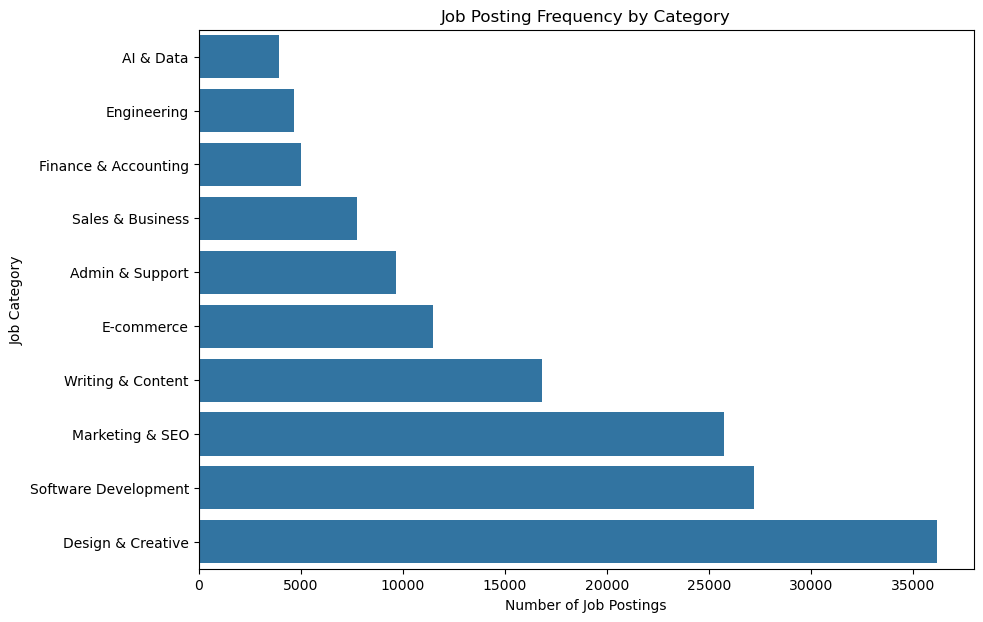

In [16]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=category_frequency_df.sort_values(
        'job_count',
        ascending=True
    ),
    x='job_count',
    y='category'
)

plt.title('Job Posting Frequency by Category')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Category')

plt.show()

In [17]:
task2_df['month'] = task2_df['published_date'].dt.to_period('M')

print(
    task2_df['month'].value_counts().sort_index()
)

month
2023-11         1
2023-12        10
2024-01        96
2024-02    101887
2024-03    142834
Freq: M, Name: count, dtype: int64


C:\Users\saket\AppData\Local\Temp\ipykernel_5900\2900335845.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  task2_df['month'] = task2_df['published_date'].dt.to_period('M')


In [18]:
monthly_category_data = []

for category, keywords_list in categories.items():

    mask = pd.Series(False, index=task2_df.index)

    for keyword in keywords_list:
        mask = mask | task2_df['title'].str.contains(
            re.escape(keyword),
            regex=True
        )

    temp = task2_df.loc[mask].groupby('month').size()

    for month, count in temp.items():

        monthly_category_data.append({
            'month': month,
            'category': category,
            'job_count': count
        })

monthly_category_df = pd.DataFrame(
    monthly_category_data
)

monthly_category_df.head()

,month,category,job_count
0,2023-12,AI & Data,1
1,2024-01,AI & Data,4
2,2024-02,AI & Data,1661
3,2024-03,AI & Data,2260
4,2024-01,Software Development,10


In [19]:
growth_data = []

for category in categories.keys():

    feb_count = monthly_category_df[
        (monthly_category_df['category'] == category) &
        (monthly_category_df['month'] == pd.Period('2024-02'))
    ]['job_count'].sum()

    mar_count = monthly_category_df[
        (monthly_category_df['category'] == category) &
        (monthly_category_df['month'] == pd.Period('2024-03'))
    ]['job_count'].sum()

    if feb_count > 0:
        growth = ((mar_count - feb_count) / feb_count) * 100
    else:
        growth = np.nan

    growth_data.append({
        'category': category,
        'february_postings': feb_count,
        'march_postings': mar_count,
        'growth_percentage': growth
    })

growth_df = pd.DataFrame(growth_data)

growth_df = growth_df.sort_values(
    'growth_percentage',
    ascending=False
)

growth_df

,category,february_postings,march_postings,growth_percentage
3,Marketing & SEO,10441,15265,46.202471
2,Design & Creative,14714,21429,45.636808
1,Software Development,11075,16126,45.607223
8,E-commerce,4695,6763,44.046858
6,Finance & Accounting,2079,2917,40.307840
5,Sales & Business,3247,4521,39.236218
9,Engineering,1961,2730,39.214686
0,AI & Data,1661,2260,36.062613
7,Admin & Support,4359,5289,21.335169
4,Writing & Content,7605,9182,20.736358


In [20]:
monthly_totals = (
    task2_df
    .groupby('month')
    .size()
    .reset_index(name='total_postings')
)

share_df = monthly_category_df.merge(
    monthly_totals,
    on='month',
    how='left'
)

share_df['posting_share'] = (
    share_df['job_count'] /
    share_df['total_postings']
) * 100

share_df.head()

,month,category,job_count,total_postings,posting_share
0,2023-12,AI & Data,1,10,10.000000
1,2024-01,AI & Data,4,96,4.166667
2,2024-02,AI & Data,1661,101887,1.630237
3,2024-03,AI & Data,2260,142834,1.582256
4,2024-01,Software Development,10,96,10.416667


In [21]:
share_growth = []

for category in categories.keys():

    feb_share = share_df[
        (share_df['category'] == category) &
        (share_df['month'] == pd.Period('2024-02'))
    ]['posting_share'].sum()

    mar_share = share_df[
        (share_df['category'] == category) &
        (share_df['month'] == pd.Period('2024-03'))
    ]['posting_share'].sum()

    share_growth.append({
        'category': category,
        'february_share': feb_share,
        'march_share': mar_share,
        'share_change_pp': mar_share - feb_share
    })

share_growth_df = pd.DataFrame(share_growth)

share_growth_df = share_growth_df.sort_values(
    'share_change_pp',
    ascending=False
)

share_growth_df

,category,february_share,march_share,share_change_pp
2,Design & Creative,14.441489,15.002730,0.561241
3,Marketing & SEO,10.247627,10.687231,0.439604
1,Software Development,10.869885,11.290029,0.420144
8,E-commerce,4.608046,4.734867,0.126821
6,Finance & Accounting,2.040496,2.042231,0.001735
9,Engineering,1.924681,1.911310,-0.013372
5,Sales & Business,3.186864,3.165213,-0.021651
0,AI & Data,1.630237,1.582256,-0.047981
7,Admin & Support,4.278269,3.702900,-0.575369
4,Writing & Content,7.464151,6.428441,-1.035710


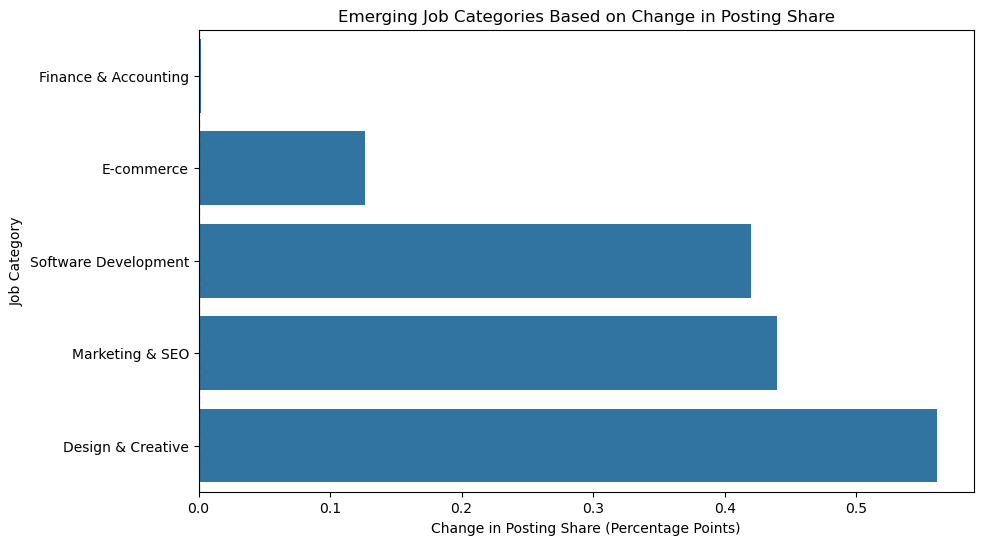

In [22]:
emerging_df = share_growth_df[
    share_growth_df['share_change_pp'] > 0
].copy()

emerging_df = emerging_df.sort_values(
    'share_change_pp',
    ascending=True
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=emerging_df,
    x='share_change_pp',
    y='category'
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--'
)

plt.title(
    'Emerging Job Categories Based on Change in Posting Share'
)

plt.xlabel('Change in Posting Share (Percentage Points)')
plt.ylabel('Job Category')

plt.show()

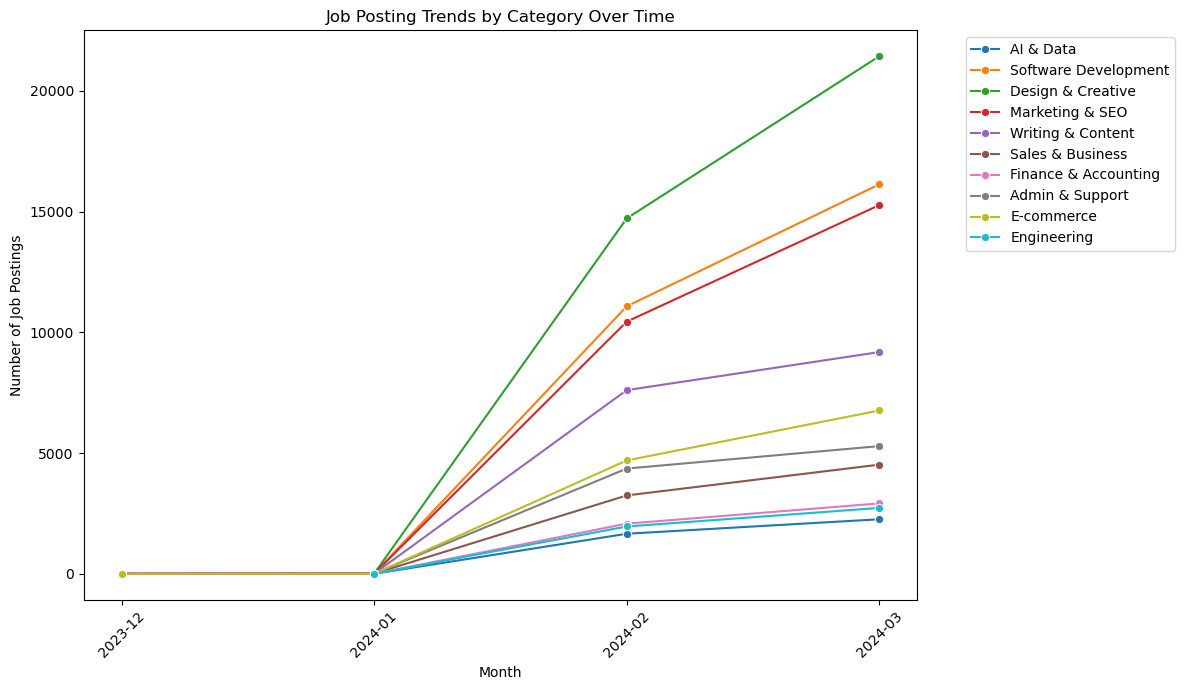

In [23]:
# Convert month to string for plotting
monthly_category_plot = monthly_category_df.copy()

monthly_category_plot['month'] = (
    monthly_category_plot['month']
    .astype(str)
)

# Plot job posting trends over time
plt.figure(figsize=(12, 7))

sns.lineplot(
    data=monthly_category_plot,
    x='month',
    y='job_count',
    hue='category',
    marker='o'
)

plt.title('Job Posting Trends by Category Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [24]:
# Prepare monthly category data for prediction

model_df = monthly_category_df.copy()

model_df['month'] = model_df['month'].astype(str)

# Create month number
month_list = sorted(model_df['month'].unique())
month_mapping = {month: i for i, month in enumerate(month_list)}

model_df['month_index'] = model_df['month'].map(month_mapping)

# Convert categories into numerical values
model_df['category_code'] = model_df['category'].astype('category').cat.codes

model_df.head()

,month,category,job_count,month_index,category_code
0,2023-12,AI & Data,1,0,0
1,2024-01,AI & Data,4,1,0
2,2024-02,AI & Data,1661,2,0
3,2024-03,AI & Data,2260,3,0
4,2024-01,Software Development,10,1,8


In [25]:
# Task 3: Time-based prediction

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Sort data by month
model_df = model_df.sort_values(
    ['month_index', 'category_code']
).reset_index(drop=True)

# Use earlier months for training
# Use the latest available month for testing

test_month = model_df['month_index'].max()

train_df = model_df[
    model_df['month_index'] < test_month
].copy()

test_df = model_df[
    model_df['month_index'] == test_month
].copy()

# Features and target
X_train = train_df[['month_index', 'category_code']]
y_train = train_df['job_count']

X_test = test_df[['month_index', 'category_code']]
y_test = test_df['job_count']

# Train Random Forest model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predict test month
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Task 3 - Time Based Model Performance")
print("--------------------------------------")
print("Test Month:", test_month)
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

Task 3 - Time Based Model Performance
--------------------------------------
Test Month: 3
MAE : 2980.02
RMSE: 4717.24
R² Score: 0.449


In [26]:
prediction_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

prediction_df.head(10)

,Actual,Predicted
0,2260,2784.22
1,5289,4079.26
2,21429,11232.52
3,6763,6916.45
4,2730,3513.85
5,2917,3345.25
6,15265,7704.38
7,4521,4821.34
8,16126,8534.08
9,9182,8130.66


In [27]:
# Predict demand for the next month

next_month_index = model_df['month_index'].max() + 1

future_data = pd.DataFrame({
    'category': model_df['category'].unique()
})

# Create category codes using the existing mapping
category_codes = (
    model_df[['category', 'category_code']]
    .drop_duplicates()
)

future_data = future_data.merge(
    category_codes,
    on='category',
    how='left'
)

future_data['month_index'] = next_month_index

# Predict next month's postings
future_data['predicted_postings'] = model.predict(
    future_data[['month_index', 'category_code']]
)

future_data = future_data.sort_values(
    'predicted_postings',
    ascending=False
).reset_index(drop=True)

future_data

,category,category_code,month_index,predicted_postings
0,Design & Creative,2,4,11232.52
1,Software Development,8,4,8534.08
2,Writing & Content,9,4,8130.66
3,Marketing & SEO,6,4,7704.38
4,E-commerce,3,4,6916.45
5,Sales & Business,7,4,4821.34
6,Admin & Support,1,4,4079.26
7,Engineering,4,4,3513.85
8,Finance & Accounting,5,4,3345.25
9,AI & Data,0,4,2784.22


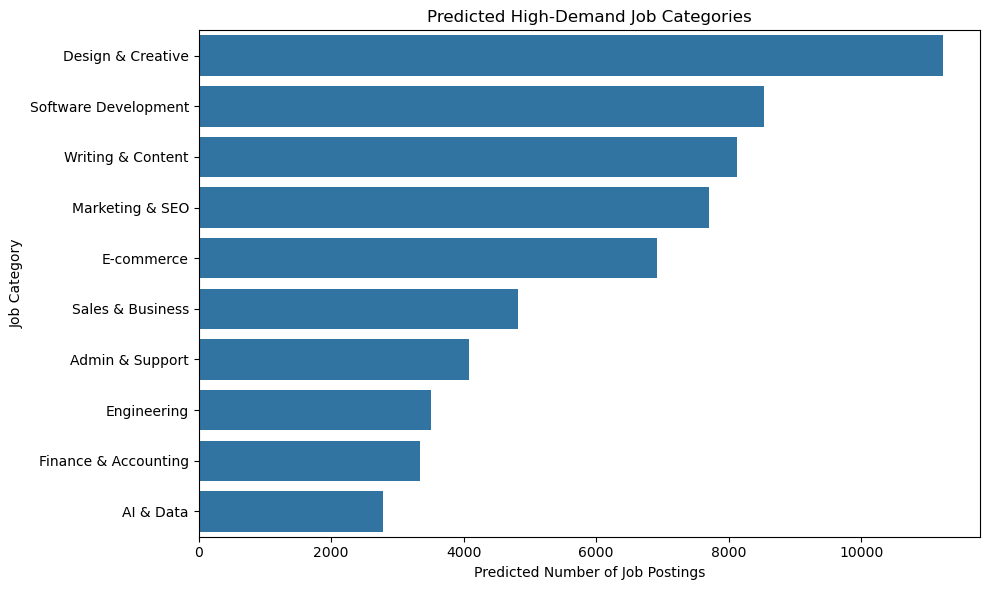

In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=future_data,
    x='predicted_postings',
    y='category'
)

plt.title('Predicted High-Demand Job Categories')
plt.xlabel('Predicted Number of Job Postings')
plt.ylabel('Job Category')

plt.tight_layout()
plt.show()

In [29]:
# Task 4: Average Hourly Rate by Country

task4_df = df.copy()

# Keep only hourly jobs
task4_df = task4_df[task4_df['is_hourly'] == True].copy()

# Calculate average hourly rate
task4_df['avg_hourly_rate'] = (
    task4_df['hourly_low'] + task4_df['hourly_high']
) / 2

# Remove missing values
country_rate_df = task4_df.dropna(
    subset=['country', 'avg_hourly_rate']
)

# Calculate average rate by country
country_avg_rate = (
    country_rate_df
    .groupby('country')['avg_hourly_rate']
    .mean()
    .sort_values(ascending=False)
)

country_avg_rate

country
Laos                        201.333333
Eritrea                     100.000000
Malawi                       75.500000
Netherlands Antilles         61.250000
Malaysia                     48.103077
                               ...    
Djibouti                     10.000000
Macao                         8.750000
Guadeloupe                    8.250000
Vanuatu                       6.500000
Central African Republic      5.000000
Name: avg_hourly_rate, Length: 191, dtype: float64

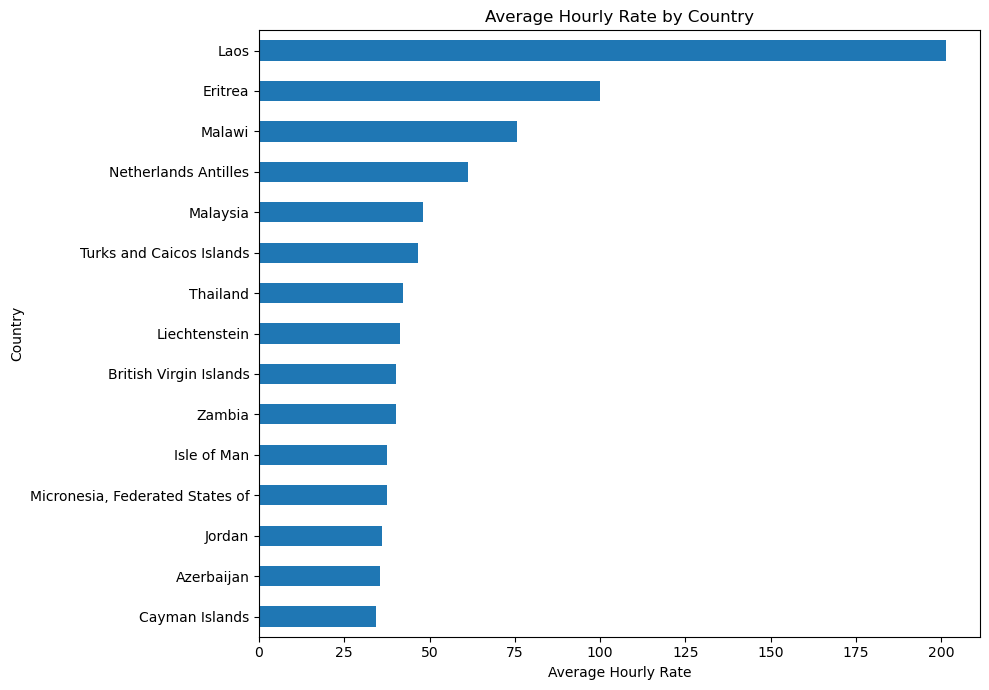

In [30]:
plt.figure(figsize=(10, 7))

country_avg_rate.head(15).sort_values().plot(
    kind='barh'
)

plt.title('Average Hourly Rate by Country')
plt.xlabel('Average Hourly Rate')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

In [31]:
# Task 5: Personalized Job Recommendation System

# Work on a copy of the original dataset
recommendation_df = df.copy()

# Remove jobs where title is missing
recommendation_df = recommendation_df.dropna(subset=['title']).copy()

# Clean title text
recommendation_df['title'] = recommendation_df['title'].astype(str).str.strip()

# Remove empty titles
recommendation_df = recommendation_df[recommendation_df['title'] != ''].copy()

print("Dataset shape for recommendation system:", recommendation_df.shape)
print("Available columns:")
print(recommendation_df.columns.tolist())

Dataset shape for recommendation system: (244827, 8)
Available columns:
['title', 'link', 'published_date', 'is_hourly', 'hourly_low', 'hourly_high', 'budget', 'country']


In [32]:
# Create TF-IDF features from job titles

tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2
)

tfidf_matrix = tfidf.fit_transform(recommendation_df['title'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (244827, 116956)


In [33]:
# Personalized Job Recommendation Function

def recommend_jobs(user_query, top_n=10, country=None, job_type=None):
    
    # Convert user query into TF-IDF
    query_vector = tfidf.transform([user_query])
    
    # Calculate similarity between user query and all job titles
    similarity_scores = cosine_similarity(query_vector, tfidf_matrix).flatten()
    
    # Create result dataframe
    results = recommendation_df.copy()
    results['similarity_score'] = similarity_scores
    
    # Apply country filter if provided
    if country is not None and country != 'All':
        results = results[
            results['country'].fillna('').str.lower() == country.lower()
        ]
    
    # Apply job type filter if provided
    if job_type == 'Hourly':
        results = results[results['is_hourly'] == True]
        
    elif job_type == 'Fixed Price':
        results = results[results['is_hourly'] == False]
    
    # Sort by similarity score
    results = results.sort_values(
        by='similarity_score',
        ascending=False
    )
    
    # Select useful columns
    output_columns = [
        'title',
        'country',
        'is_hourly',
        'hourly_low',
        'hourly_high',
        'budget',
        'link',
        'similarity_score'
    ]
    
    return results[output_columns].head(top_n)

In [34]:
# Test the recommendation system

recommendations = recommend_jobs(
    user_query='Python Data Analyst',
    top_n=10
)

recommendations

,title,country,is_hourly,hourly_low,hourly_high,budget,link,similarity_score
48017,Data Analyst,United States,True,32.0,65.0,NaN,https://www.upwork.com/jobs/Data-Analyst_%7E01...,0.689616
190444,Data Analyst,United States,True,18.0,50.0,NaN,https://www.upwork.com/jobs/Data-Analyst_%7E01...,0.689616
73263,Data analyst,United Kingdom,True,13.0,30.0,NaN,https://www.upwork.com/jobs/Data-analyst_%7E01...,0.689616
45112,Data Analyst,United States,True,NaN,NaN,NaN,https://www.upwork.com/jobs/Data-Analyst_%7E01...,0.689616
74810,Data analyst,Bangladesh,True,13.0,30.0,NaN,https://www.upwork.com/jobs/Data-analyst_%7E01...,0.689616
162963,Data Analyst,India,False,NaN,NaN,500.0,https://www.upwork.com/jobs/Data-Analyst_%7E01...,0.689616
58779,Data analyst,Puerto Rico,True,18.0,50.0,NaN,https://www.upwork.com/jobs/Data-analyst_%7E01...,0.689616
78711,Data Analyst,Switzerland,True,13.0,30.0,NaN,https://www.upwork.com/jobs/Data-Analyst_%7E01...,0.689616
36619,Data Analyst,United Kingdom,True,20.0,60.0,NaN,https://www.upwork.com/jobs/Data-Analyst_%7E01...,0.689616
86755,Data analyst,Australia,True,13.0,30.0,NaN,https://www.upwork.com/jobs/Data-analyst_%7E01...,0.689616


In [35]:
# Improved Personalized Job Recommendation Function

def recommend_jobs(
    user_query,
    top_n=10,
    country='All',
    job_type='All',
    min_hourly_rate=None,
    max_hourly_rate=None
):
    
    # Convert user query into TF-IDF
    query_vector = tfidf.transform([user_query])
    
    # Calculate similarity
    similarity_scores = cosine_similarity(
        query_vector,
        tfidf_matrix
    ).flatten()
    
    # Create result dataframe
    results = recommendation_df.copy()
    results['similarity_score'] = similarity_scores
    
    # Country filter
    if country != 'All':
        results = results[
            results['country'].fillna('').str.lower() == country.lower()
        ]
    
    # Job type filter
    if job_type == 'Hourly':
        results = results[results['is_hourly'] == True]
        
    elif job_type == 'Fixed Price':
        results = results[results['is_hourly'] == False]
    
    # Hourly rate filter
    if min_hourly_rate is not None:
        results = results[
            (results['hourly_low'].fillna(0) >= min_hourly_rate)
        ]
    
    if max_hourly_rate is not None:
        results = results[
            (results['hourly_high'].fillna(np.inf) <= max_hourly_rate)
        ]
    
    # Sort by similarity
    results = results.sort_values(
        by='similarity_score',
        ascending=False
    )
    
    # Remove duplicate job titles for more diverse recommendations
    results = results.drop_duplicates(
        subset=['title'],
        keep='first'
    )
    
    # Select useful information
    output_columns = [
        'title',
        'country',
        'is_hourly',
        'hourly_low',
        'hourly_high',
        'budget',
        'link',
        'similarity_score'
    ]
    
    return results[output_columns].head(top_n)

In [36]:
recommendations = recommend_jobs(
    user_query='Python Data Analyst',
    top_n=10,
    country='India',
    job_type='All'
)

recommendations

,title,country,is_hourly,hourly_low,hourly_high,budget,link,similarity_score
53305,Data analyst,India,True,13.0,30.0,NaN,https://www.upwork.com/jobs/Data-analyst_%7E01...,0.689616
37043,Data Analyst,India,False,NaN,NaN,3000.0,https://www.upwork.com/jobs/Data-Analyst_%7E01...,0.689616
199485,Python Data Scientist Analyst,India,True,15.0,21.0,NaN,https://www.upwork.com/jobs/Python-Data-Scient...,0.571956
40806,Data Engineer/Data Analyst,India,True,10.0,30.0,NaN,https://www.upwork.com/jobs/Data-Engineer-Data...,0.451747
45288,Data Engineer/ Data Analyst,India,False,NaN,NaN,260.0,https://www.upwork.com/jobs/Data-Engineer-Data...,0.451747
10966,Data Analyst High Level Trainer,India,False,NaN,NaN,180.0,https://www.upwork.com/jobs/Data-Analyst-High-...,0.423242
78053,Data Analyst for Data Entry Job,India,False,NaN,NaN,100.0,https://www.upwork.com/jobs/Data-Analyst-for-D...,0.412576
54671,Online Data Analyst Needed.,India,False,NaN,NaN,500.0,https://www.upwork.com/jobs/Online-Data-Analys...,0.391519
220194,AI Engineer cum Data Analyst,India,False,NaN,NaN,2000.0,https://www.upwork.com/jobs/Engineer-cum-Data-...,0.383715
190558,"VBA Developer, Data Analyst",India,True,10.0,50.0,NaN,https://www.upwork.com/jobs/VBA-Developer-Data...,0.364764


In [37]:
# Task 5: Working Prototype

print("=== Personalized Job Recommendation System ===")

user_query = input("Enter your skills or desired job role: ")

print("\nAvailable job types:")
print("1. All")
print("2. Hourly")
print("3. Fixed Price")

job_type_choice = input("Select job type (1/2/3): ")

if job_type_choice == '2':
    selected_job_type = 'Hourly'
elif job_type_choice == '3':
    selected_job_type = 'Fixed Price'
else:
    selected_job_type = 'All'

country_input = input(
    "Enter country (or type All): "
)

# Generate recommendations
prototype_results = recommend_jobs(
    user_query=user_query,
    top_n=10,
    country=country_input,
    job_type=selected_job_type
)

print("\n=== Recommended Jobs ===")

if prototype_results.empty:
    print("No matching jobs found.")
else:
    display(prototype_results)

=== Personalized Job Recommendation System ===


Enter your skills or desired job role:  All



Available job types:
1. All
2. Hourly
3. Fixed Price


Select job type (1/2/3):  1
Enter country (or type All):  India



=== Recommended Jobs ===


,title,country,is_hourly,hourly_low,hourly_high,budget,link,similarity_score
244819,API developer FastAPI,India,False,NaN,NaN,600.0,https://www.upwork.com/jobs/API-developer-Fast...,0.0
4,Data Engineer,India,False,NaN,NaN,650.0,https://www.upwork.com/jobs/Data-Engineer_%7E0...,0.0
6,Want to fix the WordPress Plugin,India,False,NaN,NaN,5.0,https://www.upwork.com/jobs/Want-fix-the-WordP...,0.0
7,need Portuguese writers who can understand and...,India,True,7.0,22.0,NaN,https://www.upwork.com/jobs/need-Portuguese-wr...,0.0
18,"Website design, UI/UX Design",India,True,12.0,30.0,NaN,https://www.upwork.com/jobs/Website-design-Des...,0.0
20,Promo Video for Game,India,False,NaN,NaN,100.0,https://www.upwork.com/jobs/Promo-Video-for-Ga...,0.0
25,Full stack Developer,India,False,NaN,NaN,5.0,https://www.upwork.com/jobs/Full-stack-Develop...,0.0
78,Homeware Product Pattern Designer,India,True,15.0,35.0,NaN,https://www.upwork.com/jobs/Homeware-Product-P...,0.0
98,"Transport, Transport planning, Capacity develo...",India,True,NaN,NaN,NaN,https://www.upwork.com/jobs/Transport-Transpor...,0.0
102,Instagram Graph API setup,India,False,NaN,NaN,20.0,https://www.upwork.com/jobs/Instagram-Graph-AP...,0.0


In [39]:
# ============================================
# Save recommendation_data.pkl only
# Keep TF-IDF files unchanged
# ============================================

import joblib
import os

# Only keep columns that the Flask API actually uses
recommendation_data_small = recommendation_df[
    [
        'title',
        'country',
        'is_hourly',
        'hourly_low',
        'hourly_high',
        'budget',
        'link'
    ]
].copy()

# Reset index
recommendation_data_small.reset_index(
    drop=True,
    inplace=True
)

# Save only the reduced recommendation data
joblib.dump(
    recommendation_data_small,
    "task5_api/recommendation_data.pkl",
    compress=9
)

# Check new file size
file_size_mb = (
    os.path.getsize(
        "task5_api/recommendation_data.pkl"
    ) / (1024 ** 2)
)

print("Recommendation data saved successfully.")
print(
    f"New recommendation_data.pkl size: "
    f"{file_size_mb:.2f} MB"
)

print("\nExisting TF-IDF files are unchanged:")
print("tfidf_vectorizer.pkl")
print("tfidf_matrix.pkl")

Recommendation data saved successfully.
New recommendation_data.pkl size: 13.31 MB

Existing TF-IDF files are unchanged:
tfidf_vectorizer.pkl
tfidf_matrix.pkl


In [40]:
# ============================================
# TASK 6: JOB MARKET DYNAMICS OVER MONTHS
# =======================================
# Original dataset copy
task6_df = df.copy()

# Date ko datetime mein convert karna
task6_df['published_date'] = pd.to_datetime(task6_df['published_date'])

# Month column banana
task6_df['month'] = task6_df['published_date'].dt.to_period('M').astype(str)

# Monthly posting count
monthly_jobs = (
    task6_df
    .groupby('month')
    .size()
    .reset_index(name='job_postings')
)

monthly_jobs

C:\Users\saket\AppData\Local\Temp\ipykernel_5900\3019118130.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  task6_df['month'] = task6_df['published_date'].dt.to_period('M').astype(str)


,month,job_postings
0,2023-11,1
1,2023-12,10
2,2024-01,96
3,2024-02,101887
4,2024-03,142834


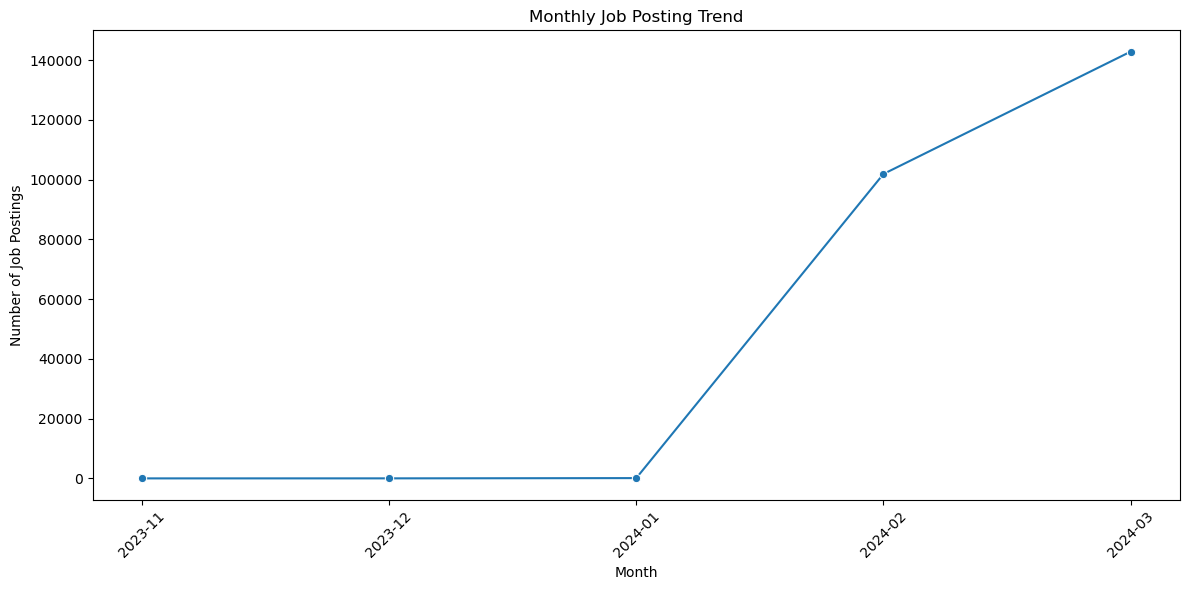

In [41]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_jobs,
    x='month',
    y='job_postings',
    marker='o'
)

plt.title('Monthly Job Posting Trend')
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
monthly_job_type = (
    task6_df
    .groupby(['month', 'is_hourly'])
    .size()
    .reset_index(name='job_count')
)

monthly_job_type['job_type'] = monthly_job_type['is_hourly'].map({
    True: 'Hourly',
    False: 'Fixed Price'
})

monthly_job_type



,month,is_hourly,job_count,job_type
0,2023-11,True,1,Hourly
1,2023-12,False,2,Fixed Price
2,2023-12,True,8,Hourly
3,2024-01,False,32,Fixed Price
4,2024-01,True,64,Hourly
5,2024-02,False,42407,Fixed Price
6,2024-02,True,59480,Hourly
7,2024-03,False,61450,Fixed Price
8,2024-03,True,81384,Hourly


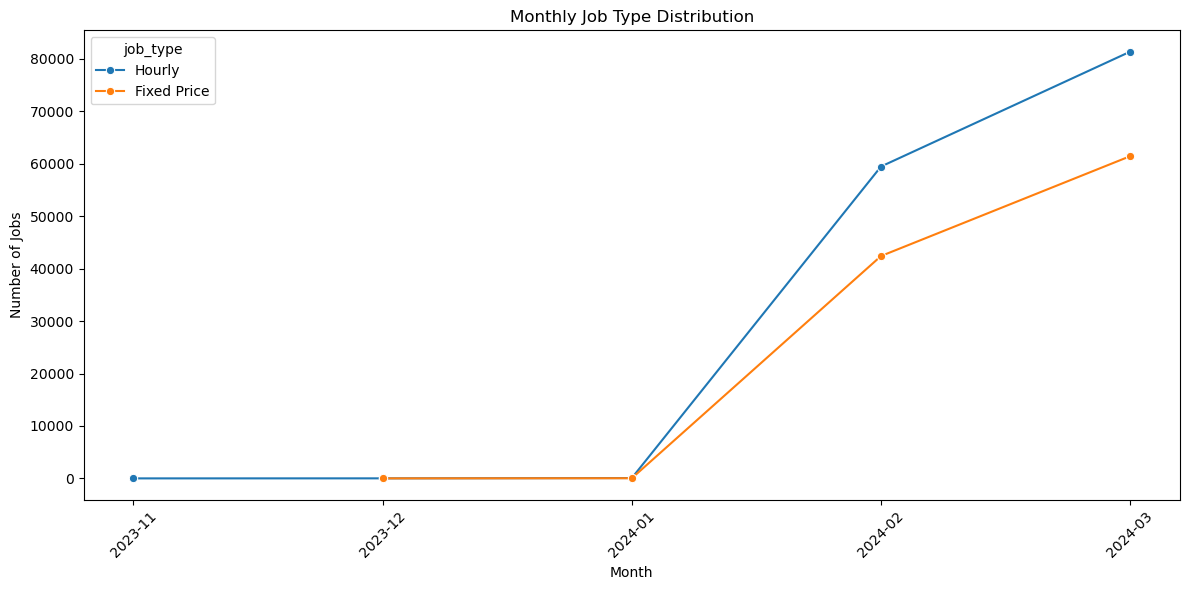

In [43]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_job_type,
    x='month',
    y='job_count',
    hue='job_type',
    marker='o'
)

plt.title('Monthly Job Type Distribution')
plt.xlabel('Month')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
hourly_df = task6_df[task6_df['is_hourly'] == True].copy()

hourly_df['avg_hourly_rate'] = (
    hourly_df['hourly_low'] + hourly_df['hourly_high']
) / 2

monthly_hourly_rate = (
    hourly_df
    .dropna(subset=['avg_hourly_rate'])
    .groupby('month')['avg_hourly_rate']
    .mean()
    .reset_index()
)

monthly_hourly_rate

,month,avg_hourly_rate
0,2023-11,37.500000
1,2023-12,30.125000
2,2024-01,23.133333
3,2024-02,29.963194
4,2024-03,29.524591


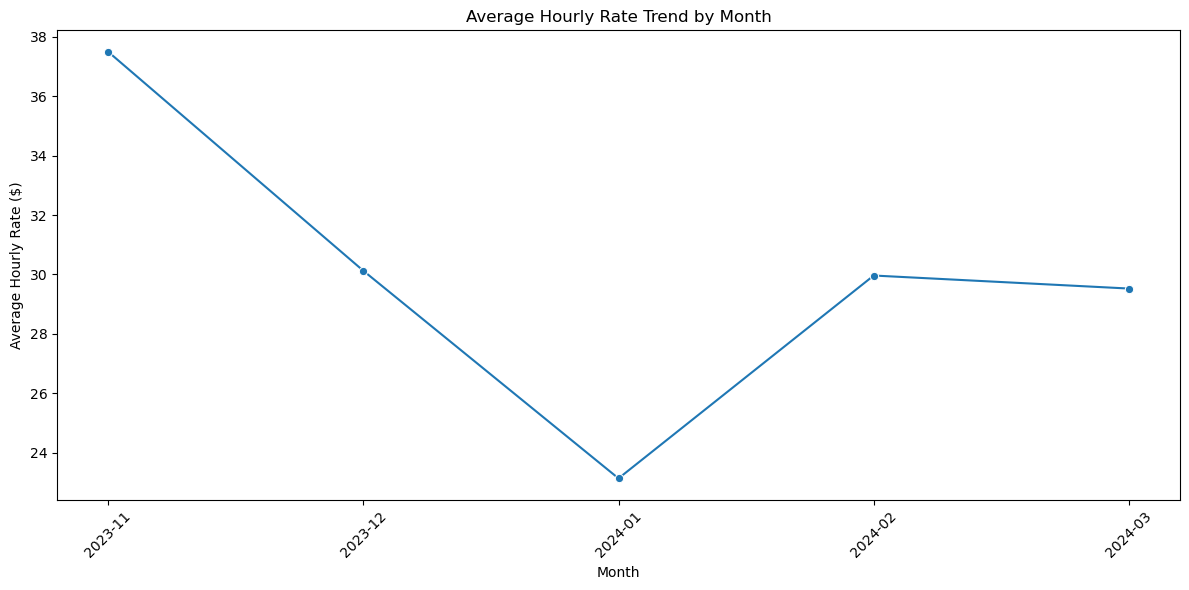

In [45]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_hourly_rate,
    x='month',
    y='avg_hourly_rate',
    marker='o'
)

plt.title('Average Hourly Rate Trend by Month')
plt.xlabel('Month')
plt.ylabel('Average Hourly Rate ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
monthly_top_titles = (
    task6_df
    .groupby(['month', 'title'])
    .size()
    .reset_index(name='job_count')
    .sort_values(['month', 'job_count'], ascending=[True, False])
)

monthly_top_titles.head(20)

,month,title,job_count
0,2023-11,Senior .NET Architect (Team Lead),1
1,2023-12,Bookkeeping and Collections Agent (Full Time R...,1
2,2023-12,Data Science / Computer Vision expert,1
3,2023-12,I am looking for a research writer to make a s...,1
4,2023-12,Marketing expert to explode the internet,1
5,2023-12,Recruiter (Full Time/Permanent/Long Term),1
6,2023-12,Ruby on Rails Expert,1
7,2023-12,Swedish Content writer needed,1
8,2023-12,URGENTLY HIRING!! Inside Sales Agents for a lo...,1
9,2023-12,Video creator for short 2-minute videos,1


In [47]:
latest_month = task6_df['month'].max()

latest_top_titles = (
    monthly_top_titles[
        monthly_top_titles['month'] == latest_month
    ]
    .head(10)
)

latest_top_titles

,month,title,job_count
186551,2024-03,Social Media Manager,245
197724,2024-03,Video Editor,202
148147,2024-03,Logo Design,201
134866,2024-03,Graphic Designer,172
199542,2024-03,Virtual Assistant,166
148745,2024-03,Logo design,100
148388,2024-03,Logo Designer,88
146109,2024-03,Lead Generation,83
130640,2024-03,Full Stack Developer,80
95614,2024-03,Appointment Setter,72


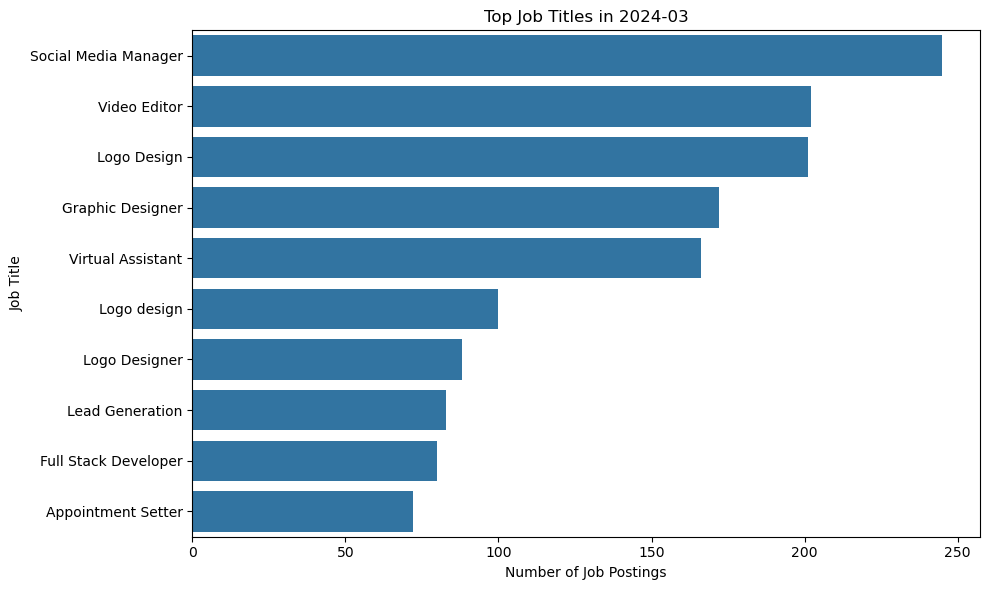

In [48]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=latest_top_titles,
    x='job_count',
    y='title'
)

plt.title(f'Top Job Titles in {latest_month}')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

In [49]:
# ==========================================
# TASK 7: REMOTE WORK LANDSCAPE ANALYSIS
# ==========================================

# Original dataset copy
task7_df = df.copy()

# Date convert into datetime
task7_df['published_date'] = pd.to_datetime(
    task7_df['published_date'],
    errors='coerce'
)

# Remote-work related keywords
remote_keywords = [
    'remote',
    'remote work',
    'work from home',
    'work-from-home',
    'wfh',
    'telecommute',
    'virtual',
    'distributed team'
]

# Title remote keywords search
pattern = '|'.join(remote_keywords)

task7_df['is_remote'] = (
    task7_df['title']
    .fillna('')
    .str.lower()
    .str.contains(pattern, regex=True, na=False)
)

# Month column
task7_df['month'] = task7_df['published_date'].dt.to_period('M')

print(task7_df[['title', 'is_remote', 'month']].head())

                                               title  is_remote    month
0  Experienced Media Buyer For Solar Pannel and R...      False  2024-02
1                               Full Stack Developer      False  2024-02
2                                    SMMA Bubble App      False  2024-02
3             Talent Hunter Specialized in Marketing      False  2024-02
4                                      Data Engineer      False  2024-02


C:\Users\saket\AppData\Local\Temp\ipykernel_5900\920428585.py:37: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  task7_df['month'] = task7_df['published_date'].dt.to_period('M')


In [50]:
# Remote vs Non-Remote job count

remote_summary = (
    task7_df['is_remote']
    .value_counts()
    .rename(index={
        True: 'Remote Jobs',
        False: 'Non-Remote Jobs'
    })
)

print(remote_summary)

is_remote
Non-Remote Jobs    239098
Remote Jobs          5730
Name: count, dtype: int64


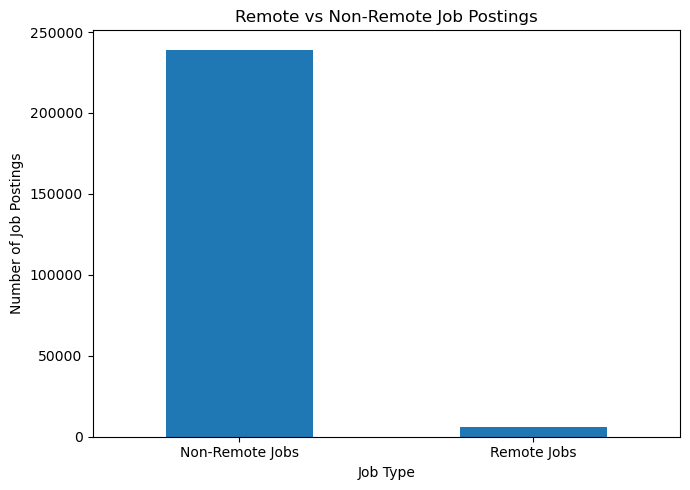

In [51]:
plt.figure(figsize=(7, 5))

remote_summary.plot(
    kind='bar'
)

plt.title('Remote vs Non-Remote Job Postings')
plt.xlabel('Job Type')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [52]:
total_jobs = len(task7_df)
remote_jobs = task7_df['is_remote'].sum()

remote_percentage = (remote_jobs / total_jobs) * 100

print(f"Total Jobs: {total_jobs:,}")
print(f"Remote Jobs: {remote_jobs:,}")
print(f"Remote Job Percentage: {remote_percentage:.2f}%")

Total Jobs: 244,828
Remote Jobs: 5,730
Remote Job Percentage: 2.34%


In [53]:
# Monthly total jobs
monthly_total_jobs = (
    task7_df
    .groupby('month')
    .size()
    .reset_index(name='total_jobs')
)

# Monthly remote jobs
monthly_remote_jobs = (
    task7_df[task7_df['is_remote'] == True]
    .groupby('month')
    .size()
    .reset_index(name='remote_jobs')
)

# Combine both tables
monthly_remote_trend = pd.merge(
    monthly_total_jobs,
    monthly_remote_jobs,
    on='month',
    how='left'
)

monthly_remote_trend['remote_jobs'] = (
    monthly_remote_trend['remote_jobs']
    .fillna(0)
)

# Remote percentage
monthly_remote_trend['remote_percentage'] = (
    monthly_remote_trend['remote_jobs']
    / monthly_remote_trend['total_jobs']
    * 100
)

# Display
monthly_remote_trend

,month,total_jobs,remote_jobs,remote_percentage
0,2023-11,1,0.0,0.000000
1,2023-12,10,0.0,0.000000
2,2024-01,96,9.0,9.375000
3,2024-02,101887,2495.0,2.448791
4,2024-03,142834,3226.0,2.258566


In [54]:
country_total = (
    task7_df
    .dropna(subset=['country'])
    .groupby('country')
    .size()
    .rename('total_jobs')
)

country_remote = (
    task7_df[task7_df['is_remote'] == True]
    .dropna(subset=['country'])
    .groupby('country')
    .size()
    .rename('remote_jobs')
)

country_remote_analysis = pd.concat(
    [country_total, country_remote],
    axis=1
).fillna(0)

country_remote_analysis['remote_percentage'] = (
    country_remote_analysis['remote_jobs']
    / country_remote_analysis['total_jobs']
    * 100
)

#Only those country where minimum jobs are are 100

country_remote_analysis = country_remote_analysis[
    country_remote_analysis['total_jobs'] >= 100
]

country_remote_analysis = country_remote_analysis.sort_values(
    'remote_percentage',
    ascending=False
)

print(country_remote_analysis.head(15))

                    total_jobs  remote_jobs  remote_percentage
country                                                       
Philippines               2426        129.0           5.317395
Czech Republic             527         27.0           5.123340
Malta                      829         32.0           3.860072
Dominican Republic         157          6.0           3.821656
Croatia                    247          9.0           3.643725
Finland                    313         11.0           3.514377
Macedonia                  204          7.0           3.431373
Nigeria                   1043         35.0           3.355705
Portugal                   807         27.0           3.345725
Moldova                    180          6.0           3.333333
Costa Rica                 185          6.0           3.243243
United States            99834       3066.0           3.071098
Estonia                    528         16.0           3.030303
Nepal                      167          5.0           2

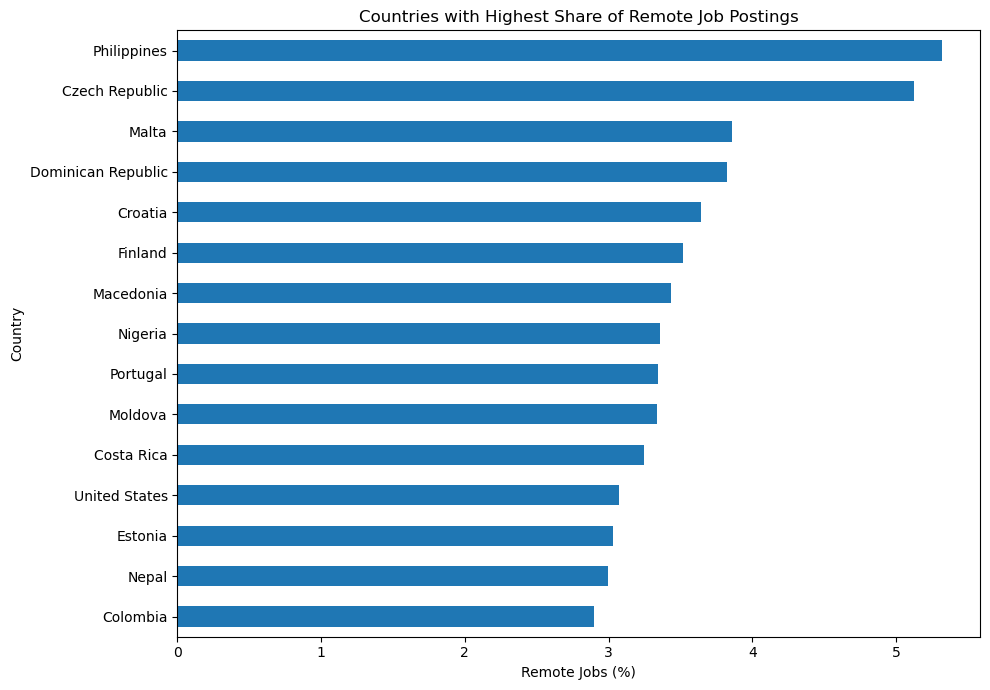

In [55]:
top_remote_percentage = country_remote_analysis.head(15)

plt.figure(figsize=(10, 7))

top_remote_percentage['remote_percentage'].sort_values().plot(
    kind='barh'
)

plt.title('Countries with Highest Share of Remote Job Postings')
plt.xlabel('Remote Jobs (%)')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

                 Fixed Price Jobs  Hourly Jobs
Non-Remote Jobs            102613       136485
Remote Jobs                  1278         4452


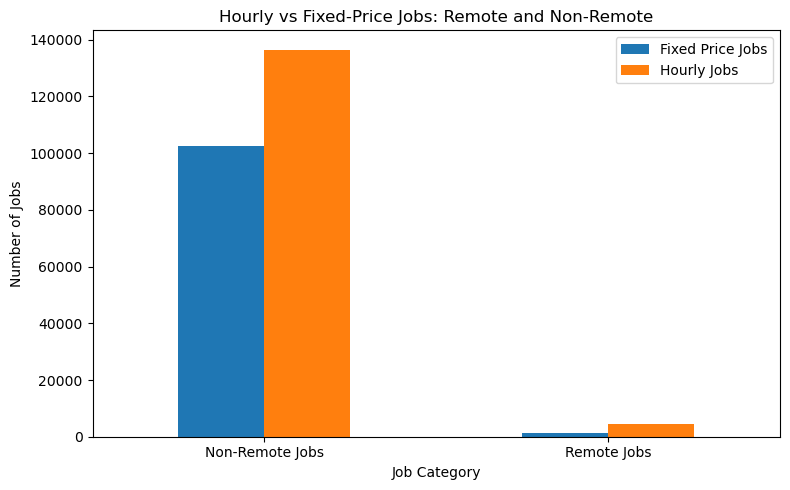

In [56]:
job_type_remote = pd.crosstab(
    task7_df['is_remote'],
    task7_df['is_hourly']
)

job_type_remote.index = [
    'Non-Remote Jobs',
    'Remote Jobs'
]

job_type_remote.columns = [
    'Fixed Price Jobs',
    'Hourly Jobs'
]

print(job_type_remote)

job_type_remote.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Hourly vs Fixed-Price Jobs: Remote and Non-Remote')
plt.xlabel('Job Category')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [57]:
forecast_df = monthly_remote_trend.copy()

forecast_df = forecast_df.sort_values('month').reset_index(drop=True)

forecast_df['month_index'] = np.arange(len(forecast_df))

forecast_df

,month,total_jobs,remote_jobs,remote_percentage,month_index
0,2023-11,1,0.0,0.000000,0
1,2023-12,10,0.0,0.000000,1
2,2024-01,96,9.0,9.375000,2
3,2024-02,101887,2495.0,2.448791,3
4,2024-03,142834,3226.0,2.258566,4


In [58]:
# Original data copy
task8_df = df.copy()

# Date conversion
task8_df['published_date'] = pd.to_datetime(
    task8_df['published_date'],
    errors='coerce'
)

# Month column
task8_df['month'] = task8_df['published_date'].dt.to_period('M')

# Monthly total job postings
monthly_market = (
    task8_df
    .groupby('month')
    .size()
    .reset_index(name='total_jobs')
)

# Month string 
monthly_market['month'] = monthly_market['month'].astype(str)

# Sequential month index
monthly_market['month_index'] = np.arange(len(monthly_market))

monthly_market

C:\Users\saket\AppData\Local\Temp\ipykernel_5900\3338453845.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  task8_df['month'] = task8_df['published_date'].dt.to_period('M')


,month,total_jobs,month_index
0,2023-11,1,0
1,2023-12,10,1
2,2024-01,96,2
3,2024-02,101887,3
4,2024-03,142834,4


In [59]:
# Hourly jobs copy
task8_hourly = task8_df[
    task8_df['is_hourly'] == True
].copy()

# Midpoint hourly rate
task8_hourly['avg_hourly_rate'] = (
    task8_hourly['hourly_low'] +
    task8_hourly['hourly_high']
) / 2

# Missing hourly rates
task8_hourly = task8_hourly.dropna(
    subset=['avg_hourly_rate']
)

# Monthly average hourly rate
monthly_hourly_rate = (
    task8_hourly
    .groupby('month')['avg_hourly_rate']
    .mean()
    .reset_index(name='average_hourly_rate')
)

monthly_hourly_rate['month'] = (
    monthly_hourly_rate['month'].astype(str)
)

monthly_hourly_rate

,month,average_hourly_rate
0,2023-11,37.500000
1,2023-12,30.125000
2,2024-01,23.133333
3,2024-02,29.963194
4,2024-03,29.524591


In [60]:
# Monthly job postings hourly rates combine
task8_monthly = pd.merge(
    monthly_market,
    monthly_hourly_rate,
    on='month',
    how='left'
)

task8_monthly

,month,total_jobs,month_index,average_hourly_rate
0,2023-11,1,0,37.500000
1,2023-12,10,1,30.125000
2,2024-01,96,2,23.133333
3,2024-02,101887,3,29.963194
4,2024-03,142834,4,29.524591


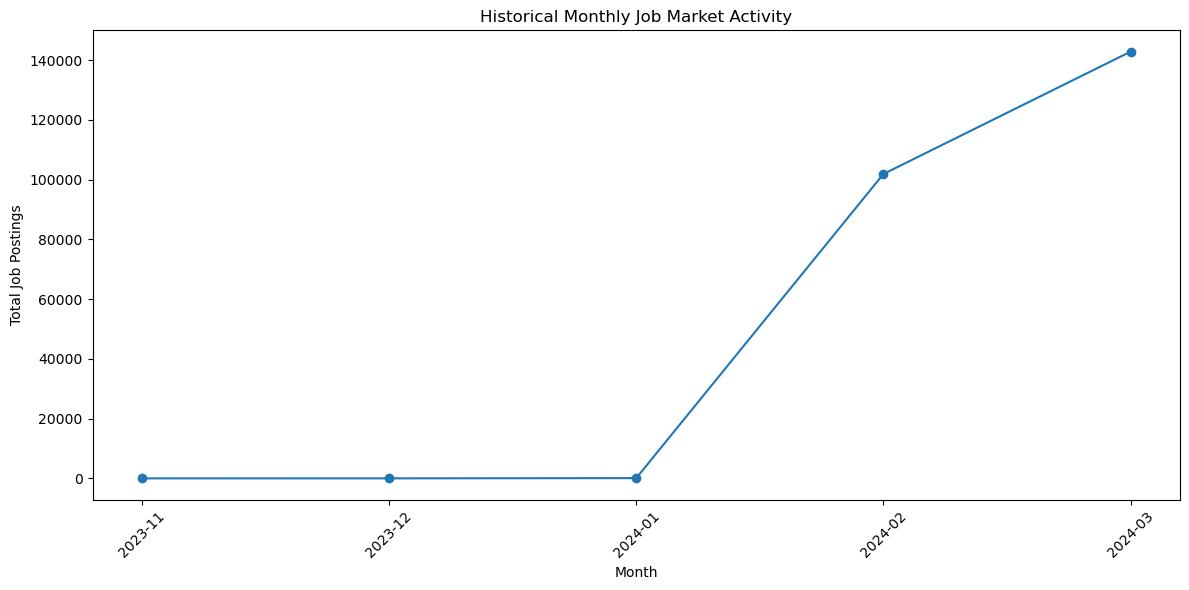

In [61]:
plt.figure(figsize=(12, 6))

plt.plot(
    task8_monthly['month'],
    task8_monthly['total_jobs'],
    marker='o'
)

plt.title('Historical Monthly Job Market Activity')
plt.xlabel('Month')
plt.ylabel('Total Job Postings')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [75]:
# Features and target
X_jobs = task8_monthly[['month_index']]
y_jobs = task8_monthly['total_jobs']

# Linear Regression model
job_market_model = LinearRegression()

job_market_model.fit(
    X_jobs,
    y_jobs
)

# Historical predictions
task8_monthly['predicted_jobs'] = (
    job_market_model.predict(X_jobs)
)

print(task8_monthly)

     month  total_jobs  month_index  average_hourly_rate  predicted_jobs
0  2023-11           1            0            37.500000        -28543.0
1  2023-12          10            1            30.125000         10211.3
2  2024-01          96            2            23.133333         48965.6
3  2024-02      101887            3            29.963194         87719.9
4  2024-03      142834            4            29.524591        126474.2


In [63]:
# Next month prediction
next_month_index = task8_monthly['month_index'].max() + 1

future_data = pd.DataFrame({
    'month_index': [next_month_index]
})

future_prediction = job_market_model.predict(future_data)[0]

print("Predicted jobs for next month:", round(future_prediction))

Predicted jobs for next month: 165228


In [64]:
mae_jobs = mean_absolute_error(
    y_jobs,
    task8_monthly['predicted_jobs']
)

rmse_jobs = np.sqrt(
    mean_squared_error(
        y_jobs,
        task8_monthly['predicted_jobs']
    )
)

r2_jobs = r2_score(
    y_jobs,
    task8_monthly['predicted_jobs']
)

print(f"MAE: {mae_jobs:.2f}")
print(f"RMSE: {rmse_jobs:.2f}")
print(f"R² Score: {r2_jobs:.3f}")

MAE: 23628.36
RMSE: 27478.77
R² Score: 0.799


In [65]:
# next index
next_month_index = task8_monthly['month_index'].max() + 1

# next month prediction
next_month_jobs_prediction = job_market_model.predict(
    [[next_month_index]]
)[0]

next_month_jobs_prediction = max(
    0,
    round(next_month_jobs_prediction)
)

print(
    f"Predicted Job Postings for Next Month: "
    f"{next_month_jobs_prediction:,}"
)

Predicted Job Postings for Next Month: 165,228


C:\Users\saket\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


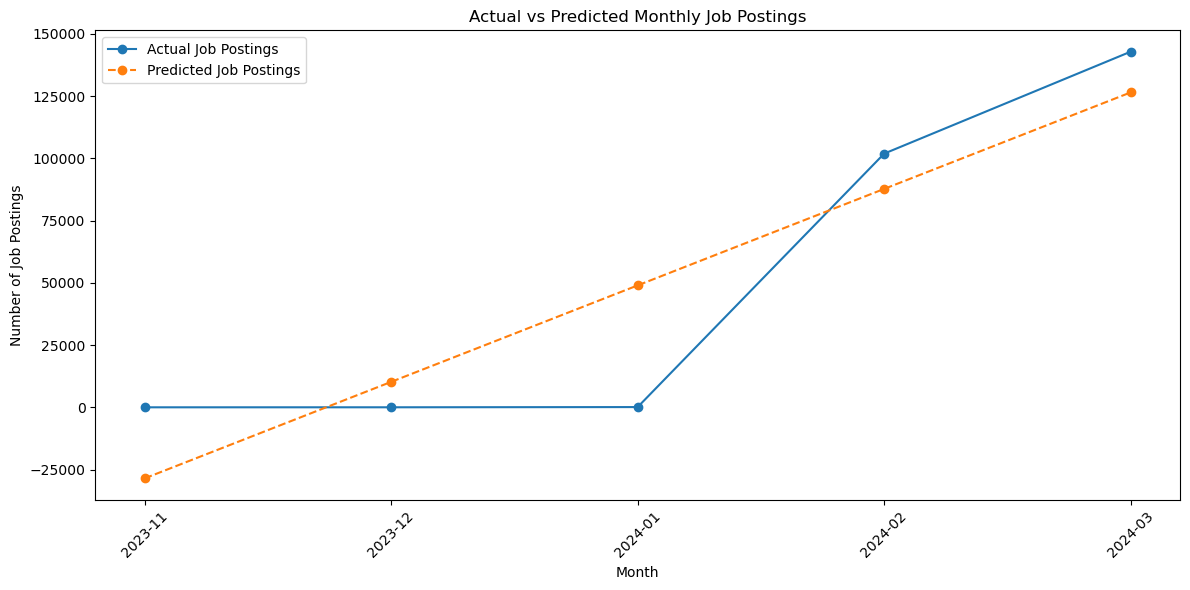

In [66]:
plt.figure(figsize=(12, 6))

plt.plot(
    task8_monthly['month'],
    task8_monthly['total_jobs'],
    marker='o',
    label='Actual Job Postings'
)

plt.plot(
    task8_monthly['month'],
    task8_monthly['predicted_jobs'],
    marker='o',
    linestyle='--',
    label='Predicted Job Postings'
)

plt.title('Actual vs Predicted Monthly Job Postings')
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [67]:
# valid hourly-rate months
rate_forecast_df = task8_monthly.dropna(
    subset=['average_hourly_rate']
).copy()

X_rate = rate_forecast_df[['month_index']]
y_rate = rate_forecast_df['average_hourly_rate']

rate_model = LinearRegression()

rate_model.fit(
    X_rate,
    y_rate
)

rate_forecast_df['predicted_hourly_rate'] = (
    rate_model.predict(X_rate)
)

print(rate_forecast_df)

     month  total_jobs  month_index  average_hourly_rate  predicted_jobs  \
0  2023-11           1            0            37.500000        -28543.0   
1  2023-12          10            1            30.125000         10211.3   
2  2024-01          96            2            23.133333         48965.6   
3  2024-02      101887            3            29.963194         87719.9   
4  2024-03      142834            4            29.524591        126474.2   

   predicted_hourly_rate  
0              33.271748  
1              31.660486  
2              30.049224  
3              28.437961  
4              26.826699  


In [68]:
mae_rate = mean_absolute_error(
    y_rate,
    rate_forecast_df['predicted_hourly_rate']
)

rmse_rate = np.sqrt(
    mean_squared_error(
        y_rate,
        rate_forecast_df['predicted_hourly_rate']
    )
)

r2_rate = r2_score(
    y_rate,
    rate_forecast_df['predicted_hourly_rate']
)

print(f"Hourly Rate MAE: {mae_rate:.2f}")
print(f"Hourly Rate RMSE: {rmse_rate:.2f}")
print(f"Hourly Rate R² Score: {r2_rate:.3f}")

Hourly Rate MAE: 3.38
Hourly Rate RMSE: 3.94
Hourly Rate R² Score: 0.251


In [69]:
next_month_rate_prediction = rate_model.predict(
    [[next_month_index]]
)[0]

next_month_rate_prediction = max(
    0,
    round(next_month_rate_prediction, 2)
)

print(
    f"Predicted Average Hourly Rate for Next Month: "
    f"${next_month_rate_prediction}"
)

Predicted Average Hourly Rate for Next Month: $25.22


C:\Users\saket\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


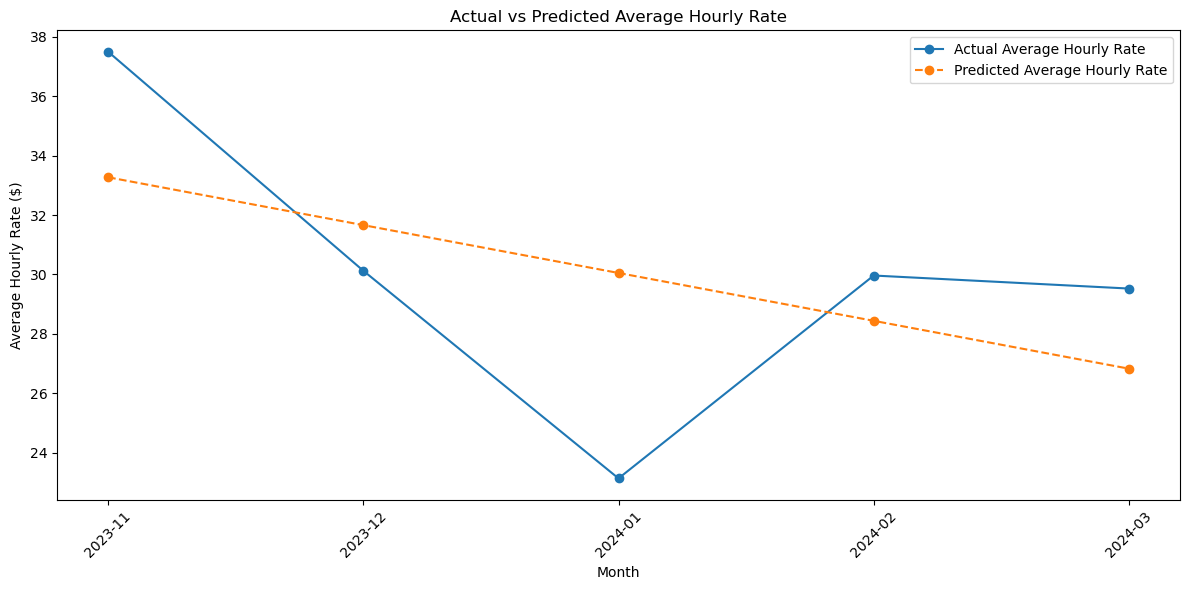

In [70]:
plt.figure(figsize=(12, 6))

plt.plot(
    rate_forecast_df['month'],
    rate_forecast_df['average_hourly_rate'],
    marker='o',
    label='Actual Average Hourly Rate'
)

plt.plot(
    rate_forecast_df['month'],
    rate_forecast_df['predicted_hourly_rate'],
    marker='o',
    linestyle='--',
    label='Predicted Average Hourly Rate'
)

plt.title('Actual vs Predicted Average Hourly Rate')
plt.xlabel('Month')
plt.ylabel('Average Hourly Rate ($)')

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [71]:
# ==========================================
# FUTURE JOB MARKET SCENARIOS
# ==========================================

last_month_jobs = task8_monthly['total_jobs'].iloc[-1]

# Conservative:
conservative_jobs = round(
    last_month_jobs * 0.90
)

# Expected: Model forecast
expected_jobs = next_month_jobs_prediction

# Growth:
growth_jobs = round(
    last_month_jobs * 1.10
)

scenario_df = pd.DataFrame({
    'Scenario': [
        'Conservative',
        'Expected',
        'Growth'
    ],
    'Predicted_Job_Postings': [
        conservative_jobs,
        expected_jobs,
        growth_jobs
    ]
})

scenario_df

,Scenario,Predicted_Job_Postings
0,Conservative,128551
1,Expected,165228
2,Growth,157117


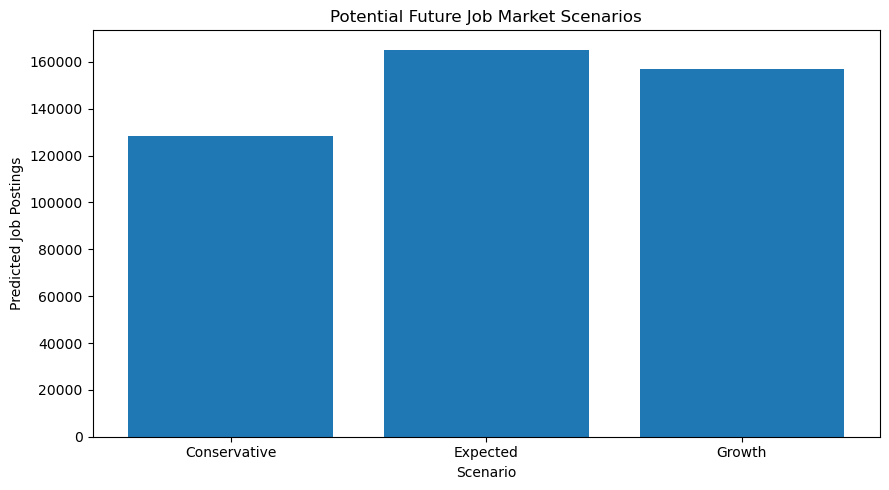

In [72]:
plt.figure(figsize=(9, 5))

plt.bar(
    scenario_df['Scenario'],
    scenario_df['Predicted_Job_Postings']
)

plt.title('Potential Future Job Market Scenarios')
plt.xlabel('Scenario')
plt.ylabel('Predicted Job Postings')

plt.tight_layout()
plt.show()

In [73]:
task8_summary = pd.DataFrame({
    'Metric': [
        'Last Observed Month',
        'Last Month Job Postings',
        'Expected Next Month Job Postings',
        'Conservative Scenario',
        'Growth Scenario',
        'Expected Next Month Average Hourly Rate'
    ],
    'Value': [
        task8_monthly['month'].iloc[-1],
        int(last_month_jobs),
        expected_jobs,
        conservative_jobs,
        growth_jobs,
        next_month_rate_prediction
    ]
})

task8_summary

,Metric,Value
0,Last Observed Month,2024-03
1,Last Month Job Postings,142834
2,Expected Next Month Job Postings,165228
3,Conservative Scenario,128551
4,Growth Scenario,157117
5,Expected Next Month Average Hourly Rate,25.22


In [74]:
task8_summary = pd.DataFrame({
    'Metric': [
        'Last Observed Month',
        'Last Month Job Postings',
        'Expected Next Month Job Postings',
        'Conservative Scenario',
        'Growth Scenario',
        'Expected Next Month Average Hourly Rate'
    ],
    'Value': [
        task8_monthly['month'].iloc[-1],
        int(last_month_jobs),
        expected_jobs,
        conservative_jobs,
        growth_jobs,
        next_month_rate_prediction
    ]
})

task8_summary

,Metric,Value
0,Last Observed Month,2024-03
1,Last Month Job Postings,142834
2,Expected Next Month Job Postings,165228
3,Conservative Scenario,128551
4,Growth Scenario,157117
5,Expected Next Month Average Hourly Rate,25.22
